In [9]:
# 1 LOAD MODULES 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import tensorflow as tf
from collections import Counter
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D ,Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping



In [2]:
# 2 PREPROCESS THE DATA AND DATA  AUGEMENTATION
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_CPP_MIN_VLOG_LEVEL'] = '3'


datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=(0.7, 1.3),
    shear_range=0.2,
    fill_mode='nearest',
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "../FOMO/dataset/train",
    target_size=(96, 96),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "../FOMO/dataset/train",
    target_size=(96, 96),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)



Found 3788 images belonging to 4 classes.
Found 946 images belonging to 4 classes.


In [4]:
print(train_data.class_indices)
labels = train_data.classes  
class_counts = Counter(labels)
index_to_class = {v: k for k, v in train_data.class_indices.items()}

for class_index, count in class_counts.items():
    print(f"{index_to_class[class_index]}: {count} images")


{'cocci': 0, 'healthy': 1, 'ncd': 2, 'others': 3}
cocci: 828 images
healthy: 1000 images
ncd: 1000 images
others: 960 images


In [11]:
# 3 LOADING A PRETRAINED MODEL
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  

#OUR OWN TOP LAYER
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    Dense(4, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()



2025-06-09 23:27:37.590102: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# 4 TRAINING THE MODEL
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, min_delta=0.001,)


history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,  
    callbacks=[early_stopping]
)



/home/takudzwa/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
  1/119 ━━━━━━━━━━━━━━━━━━━━ 12:56 7s/step - accuracy: 0.1875 - loss: 4.9201

2025-06-09 23:27:52.118154: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28311552 exceeds 10% of free system memory.
2025-06-09 23:27:52.147594: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29503488 exceeds 10% of free system memory.


  2/119 ━━━━━━━━━━━━━━━━━━━━ 2:07 1s/step - accuracy: 0.2031 - loss: 4.8120 

2025-06-09 23:27:53.229332: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28311552 exceeds 10% of free system memory.
2025-06-09 23:27:53.254788: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29503488 exceeds 10% of free system memory.
2025-06-09 23:27:54.309916: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28311552 exceeds 10% of free system memory.


119/119 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.6969 - loss: 2.8564 - val_accuracy: 0.7780 - val_loss: 1.6798
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.8374 - loss: 1.4450 - val_accuracy: 0.8245 - val_loss: 1.1454
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.8547 - loss: 1.0601 - val_accuracy: 0.7970 - val_loss: 1.0054
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.8555 - loss: 0.8890 - val_accuracy: 0.8171 - val_loss: 0.8796
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.8500 - loss: 0.8158 - val_accuracy: 0.8087 - val_loss: 0.8312
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.8594 - loss: 0.7776 - val_accuracy: 0.8034 - val_loss: 0.8136
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.8679 - loss: 0.7393 - val_accuracy: 0.8192 - val_loss: 0.7900
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.8605 - loss: 0.7482 - val_accuracy: 0.826

In [ ]:
#VALIDATION FO THE MODEL
val_images, val_labels = next(val_data) 
evaluation = model.evaluate(val_images, val_labels)
print(f"Cloud Model Loss: {evaluation[0]}")
print(f" Cloud Model Accuracy: {evaluation[1]}")


In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [7]:
model = model.save("broiler_model_farmer_hub.keras")
django_converter = tf.lite.TFLiteConverter.from_keras_model(model)
django_tflite_model = django_converter.convert()
django_path = '/home/takudzwa/Documents/Projects/broiler_disease/final_year_broiler/fomo_model.tflite'
with open(django_path, 'wb') as f:
    f.write(django_tflite_model)
print(f"Django model saved to: {django_path}")
print(f"Django model size: {len(django_tflite_model)/1024:.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpb95upvlh/assets


INFO:tensorflow:Assets written to: /tmp/tmpb95upvlh/assets


Saved artifact at '/tmp/tmpb95upvlh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  128490659373200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128490659433984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128490659436096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128490659380064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128490659431696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128490659435392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128490659439968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128490659441376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128490659437680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128490659439088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128490659432752

W0000 00:00:1749467989.120557   35361 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1749467989.120611   35361 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-06-09 13:19:49.121459: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpb95upvlh
2025-06-09 13:19:49.141619: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-06-09 13:19:49.141653: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpb95upvlh
I0000 00:00:1749467989.336203   35361 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2025-06-09 13:19:49.362260: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-06-09 13:19:50.320741: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpb95upvlh
2025-06-09 13:19:50.551880: I tensorflow/cc/saved_model/loader.cc:466] SavedModel 

Django model saved to: /home/takudzwa/Documents/Projects/broiler_disease/final_year_broiler/fomo_model.tflite
Django model size: 9299.38 KB


In [16]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "../FOMO/dataset/test", 
    target_size=(96, 96),  
    batch_size=32,
    class_mode="categorical",
    shuffle=False 
)

Found 239 images belonging to 3 classes.


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Get model predictions
y_pred = model.predict(val_images)

# Convert predictions to class labels (assuming threshold of 0.5)
y_pred_classes = (y_pred > 0.5).astype(int)

# Calculate Precision, Recall, and F1-score
precision = precision_score(val_labels, y_pred_classes, average="weighted")
recall = recall_score(val_labels, y_pred_classes, average="weighted")
f1 = f1_score(val_labels, y_pred_classes, average="weighted")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Precision: 0.8722
Recall: 0.6875
F1-score: 0.7085


In [18]:
import numpy as np

predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes 

/home/takudzwa/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step  


In [19]:
model.save("broiler_model.keras")

In [23]:
# import tensorflow as tf
# # Load your Keras model
# model = tf.keras.models.load_model('broiler_model.keras')
# esp_model = tf.keras.models.load_model('broiler_esp32model.keras')

# # 1. FOR ESP32
# def representative_data_gen():
#     for i in range(100):
#         image, _ = next(train_data) 
#         yield [image[0:1]]

# esp32_converter = tf.lite.TFLiteConverter.from_keras_model(esp_model)
# esp32_converter.optimizations = [tf.lite.Optimize.DEFAULT]
# esp32_converter.representative_dataset = representative_data_gen
# esp32_converter.inference_input_type = tf.int8
# esp32_converter.inference_output_type = tf.int8
# esp32_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# esp32_tflite_model = esp32_converter.convert()

# # Save the ESP32 model
# esp32_path = '/home/takudzwa/Documents/PlatformIO/Projects/model_convertion/broiler_disease_esp32.tflite'
# with open(esp32_path, 'wb') as f:
#     f.write(esp32_tflite_model)
# print(f"ESP32 model saved to: {esp32_path}")
# print(f"ESP32 quantized model size: {len(esp32_tflite_model) / 1024:.2f} KB")

# # 2. 
# django_converter = tf.lite.TFLiteConverter.from_keras_model(model)
# django_tflite_model = django_converter.convert()

# # Save the Django model
# django_path = '/home/takudzwa/Documents/Projects/broiler_disease/final_year_broiler/fomo_model.tflite'
# with open(django_path, 'wb') as f:
#     f.write(django_tflite_model)
# print(f"Django model saved to: {django_path}")
# print(f"Django model size: {len(django_tflite_model)/1024:.2f} KB")



In [27]:
import tensorflow as tf
interpreter = tf.lite.Interpreter(model_path="/home/takudzwa/Documents/PlatformIO/Projects/model_convertion/broiler_disease_esp32.tflite")
interpreter.allocate_tensors()

# List all ops in the model
for op in interpreter._get_ops_details():
    print(op['op_name'])

CONV_2D
MAX_POOL_2D
CONV_2D
MAX_POOL_2D
MEAN
FULLY_CONNECTED
FULLY_CONNECTED
SOFTMAX
DELEGATE


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [26]:
#EXPORTING THE MODEL TO TENSORFLOW LITE FORMAT
# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# tflite_model = converter.convert()

# with open("/home/takudzwa/Documents/Projects/broiler_disease/final_year_broiler/fomo_model.tflite", "wb") as f:
#     f.write(tflite_model)

# import tensorflow as tf


Predicted disease: cocci
Probability: 0.6252


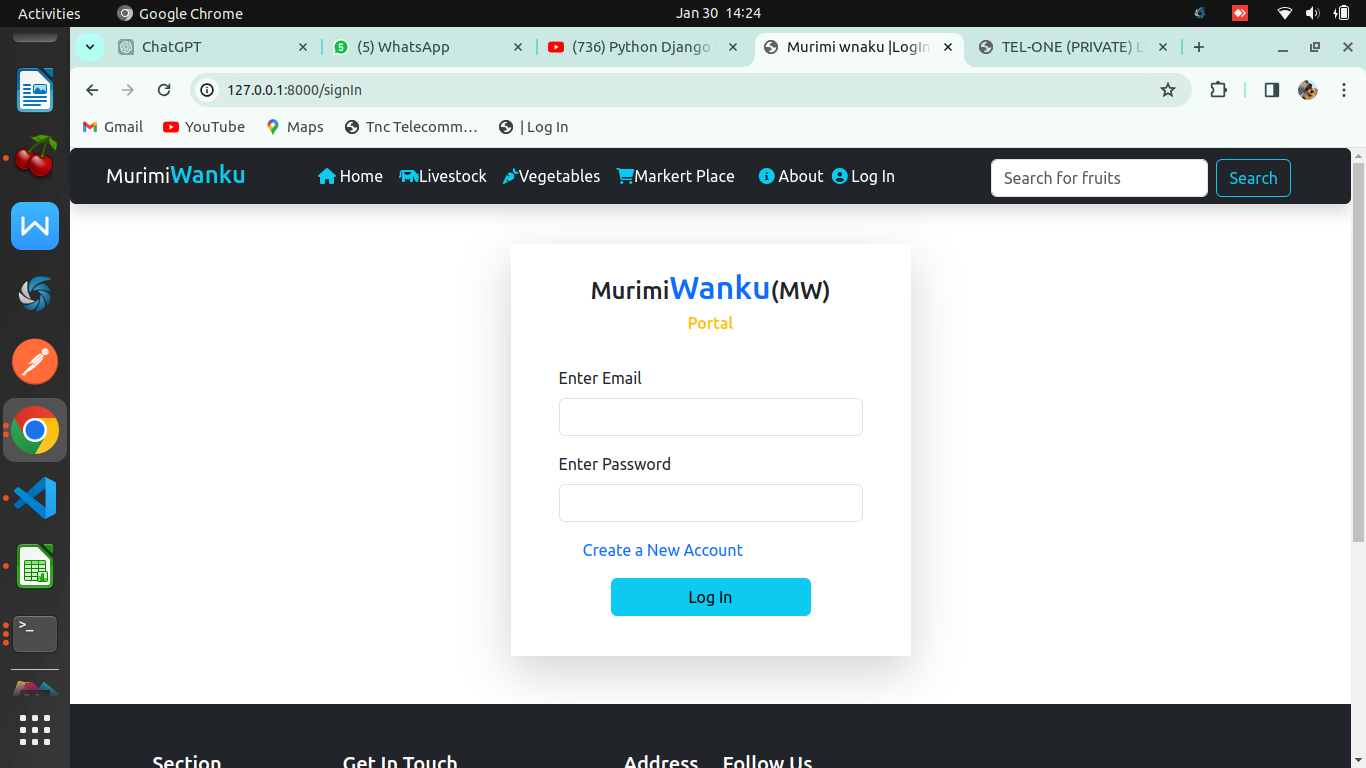

In [22]:

#TESTING THE MODEL


import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os
from PIL import Image
from IPython.display import display

# Load the TensorFlow Lite model
interpreter = tf.lite.Interpreter(model_path="/home/takudzwa/Documents/Projects/broiler_disease/final_year_broiler/fomo_model.tflite")
interpreter.allocate_tensors()

# Get input and output tensors.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load and preprocess the image
def predict_image(image_path):
    img = image.load_img(image_path, target_size=(96, 96))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    interpreter.set_tensor(input_details[0]['index'], img_array.astype(np.float32))
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return output_data


class_names = sorted(os.listdir("../FOMO/dataset/train")) 

# image_path = "/home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/test/healthy/healthy.472.jpg" 
# image_path = "/home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/test/ncd/ncd.256.jpg" 
# image_path = "/home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/test/cocci/cocci.492.jpg" 
image_path = "/home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/practice/down.png" 




# Get the prediction
predictions = predict_image(image_path)
predicted_class_index = np.argmax(predictions, axis=1)[0]
predicted_probability = predictions[0][predicted_class_index]
predicted_class_name = class_names[predicted_class_index]

# Print the results
print(f"Predicted disease: {predicted_class_name}")
print(f"Probability: {predicted_probability:.4f}")

# Display the image in the notebook
display_img = Image.open(image_path)
display(display_img) # Use display() instead of show()